In [8]:
from pathlib import Path
import yaml
import torch

from ultralytics import YOLO

BASE_DIR = Path.cwd()

DEEPPCB_DIR = (
    BASE_DIR
    / "extracted_dataset"
    / "DeepPCB"
)

RUNS_DIR = BASE_DIR / "training_runs"

print("DeepPCB exists:", DEEPPCB_DIR.exists())
print("DeepPCB path:", DEEPPCB_DIR)

DeepPCB exists: True
DeepPCB path: /home/jupyter-svecwai/Subbarao/anamoly_rv/extracted_dataset/DeepPCB


In [9]:
CLASS_FILE = DEEPPCB_DIR / "Class.txt"

with open(CLASS_FILE, "r", encoding="utf-8") as file:
    raw_text = file.read().strip()

print("Raw class file:")
print(raw_text)

Raw class file:
'open','short','mousebite','spur','copper','pin-hole'


In [10]:
import ast

try:
    nnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnn
    parsed = ast.literal_eval(raw_text)

    if isinstance(parsed, (list, tuple)):
        CLASS_NAMES = [str(name).strip() for name in parsed]
    else:
        CLASS_NAMES = [line.strip() for line in raw_text.splitlines() if line.strip()]

except Exception:
    CLASS_NAMES = [
        part.strip().strip("'\"")
        for part in raw_text.replace("[", "").replace("]", "").split(",")
        if part.strip()
    ]

print("Classes:", CLASS_NAMES)
print("Number of classes:", len(CLASS_NAMES))

Classes: ['open', 'short', 'mousebite', 'spur', 'copper', 'pin-hole']
Number of classes: 6


In [11]:
DEEPPCB_YAML = BASE_DIR / "deeppcb_data.yaml"

deep_config = {
    "train": str(DEEPPCB_DIR / "train" / "images"),
    "val": str(DEEPPCB_DIR / "valid" / "images"),
    "test": str(DEEPPCB_DIR / "test" / "images"),
    "nc": len(CLASS_NAMES),
    "names": CLASS_NAMES
}

with open(DEEPPCB_YAML, "w") as file:
    yaml.safe_dump(deep_config, file, sort_keys=False)

print("Created:", DEEPPCB_YAML)

with open(DEEPPCB_YAML, "r") as file:
    print(file.read())

Created: /home/jupyter-svecwai/Subbarao/anamoly_rv/deeppcb_data.yaml
train: /home/jupyter-svecwai/Subbarao/anamoly_rv/extracted_dataset/DeepPCB/train/images
val: /home/jupyter-svecwai/Subbarao/anamoly_rv/extracted_dataset/DeepPCB/valid/images
test: /home/jupyter-svecwai/Subbarao/anamoly_rv/extracted_dataset/DeepPCB/test/images
nc: 6
names:
- open
- short
- mousebite
- spur
- copper
- pin-hole



In [12]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

for split in ["train", "valid", "test"]:
    image_dir = DEEPPCB_DIR / split / "images"
    label_dir = DEEPPCB_DIR / split / "labels"

    images = [
        file for file in image_dir.iterdir()
        if file.suffix.lower() in image_extensions
    ]

    labels = list(label_dir.glob("*.txt"))

    print(
        f"{split:<6} images: {len(images):<5} labels: {len(labels)}"
    )

train  images: 1200  labels: 1200
valid  images: 150   labels: 150
test   images: 150   labels: 150


In [13]:
sample_labels = list(
    (DEEPPCB_DIR / "train" / "labels").glob("*.txt")
)[:5]

for label_path in sample_labels:
    print("\nFile:", label_path.name)

    with open(label_path, "r") as file:
        for line in file.readlines()[:5]:
            print(line.strip())


File: 01_PCB__55.txt
2 0.232031 0.557813 0.054688 0.043750
1 0.246875 0.354687 0.078125 0.040625
2 0.405469 0.231250 0.073438 0.056250
2 0.583594 0.271875 0.064062 0.068750
3 0.124219 0.569531 0.054688 0.042188

File: 01_PCB__506.txt
0 0.279687 0.211719 0.043750 0.057813
0 0.709375 0.099219 0.040625 0.054688
1 0.246094 0.078125 0.067187 0.065625
1 0.226562 0.446094 0.040625 0.067187
2 0.621094 0.199219 0.057813 0.054688

File: 01_PCB__220.txt
0 0.092188 0.346094 0.056250 0.051562
2 0.464062 0.258594 0.065625 0.048438
0 0.198437 0.913281 0.053125 0.054688
2 0.332031 0.600000 0.064062 0.062500
5 0.610156 0.689844 0.051562 0.045312

File: 01_PCB__1160.txt
0 0.390625 0.871875 0.068750 0.062500
1 0.518750 0.301563 0.050000 0.071875
2 0.225000 0.325000 0.071875 0.059375
3 0.364063 0.132031 0.053125 0.060937
4 0.700000 0.144531 0.062500 0.048438

File: 01_PCB__430.txt
0 0.072656 0.692187 0.051562 0.053125
1 0.307812 0.431250 0.053125 0.053125
2 0.546875 0.424219 0.059375 0.039062
3 0.564844 

In [14]:
if torch.cuda.is_available():
    DEVICE = 0
    print("GPU:", torch.cuda.get_device_name(0))
else:
    DEVICE = "cpu"
    print("GPU not available. Using CPU.")

GPU: Quadro GV100


In [15]:
MODEL_PATH = BASE_DIR / "yolov8n.pt"

print("Model exists:", MODEL_PATH.exists())

model = YOLO(str(MODEL_PATH))

print("YOLOv8n loaded successfully")

Model exists: True
YOLOv8n loaded successfully


In [16]:
from pathlib import Path

BASE_DIR = Path.cwd()

DEEPPCB_DIR = (
    BASE_DIR
    / "extracted_dataset"
    / "DeepPCB"
)

print("DeepPCB exists:", DEEPPCB_DIR.exists())
print("DeepPCB path:", DEEPPCB_DIR)

DeepPCB exists: True
DeepPCB path: /home/jupyter-svecwai/Subbarao/anamoly_rv/extracted_dataset/DeepPCB


In [17]:
import shutil

BACKUP_DIR = BASE_DIR / "DeepPCB_original_labels_backup"

if not BACKUP_DIR.exists():
    for split in ["train", "valid", "test"]:
        source = DEEPPCB_DIR / split / "labels"
        destination = BACKUP_DIR / split / "labels"

        destination.parent.mkdir(parents=True, exist_ok=True)
        shutil.copytree(source, destination)

    print("Original labels backed up to:", BACKUP_DIR)
else:
    print("Backup already exists:", BACKUP_DIR)

Backup already exists: /home/jupyter-svecwai/Subbarao/anamoly_rv/DeepPCB_original_labels_backup


In [21]:
from PIL import Image

image_extensions = [".jpg", ".jpeg", ".png", ".bmp"]

def find_matching_image(image_dir, stem):
    for extension in image_extensions:
        image_path = image_dir / f"{stem}{extension}"

        if image_path.exists():
            return image_path

        upper_path = image_dir / f"{stem}{extension.upper()}"

        if upper_path.exists():
            return upper_path

    return None


def convert_deeppcb_split(split):
    image_dir = DEEPPCB_DIR / split / "images"
    label_dir = DEEPPCB_DIR / split / "labels"

    converted_count = 0
    skipped_count = 0
    invalid_rows = 0

    label_files = list(label_dir.glob("*.txt"))

    for label_path in label_files:
        image_path = find_matching_image(image_dir, label_path.stem)

        if image_path is None:
            print("Image not found for:", label_path.name)
            skipped_count += 1
            continue

        with Image.open(image_path) as image:
            image_width, image_height = image.size

        converted_lines = []

        with open(label_path, "r") as file:
            lines = file.readlines()

        for line in lines:
            parts = line.strip().split()

            if len(parts) != 5:
                invalid_rows += 1
                continue

            try:
                x_min, y_min, x_max, y_max = map(float, parts[:4])
                old_class_id = int(float(parts[4]))
            except ValueError:
                invalid_rows += 1
                continue

            # DeepPCB classes are 1–6; YOLO classes must be 0–5
            class_id = old_class_id - 1

            if class_id < 0 or class_id > 5:
                print(
                    f"Invalid class {old_class_id} in {label_path.name}"
                )
                invalid_rows += 1
                continue

            # Keep coordinates inside image boundaries
            x_min = max(0, min(x_min, image_width))
            x_max = max(0, min(x_max, image_width))
            y_min = max(0, min(y_min, image_height))
            y_max = max(0, min(y_max, image_height))

            if x_max <= x_min or y_max <= y_min:
                invalid_rows += 1
                continue

            x_center = ((x_min + x_max) / 2) / image_width
            y_center = ((y_min + y_max) / 2) / image_height
            box_width = (x_max - x_min) / image_width
            box_height = (y_max - y_min) / image_height

            converted_lines.append(
                f"{class_id} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{box_width:.6f} "
                f"{box_height:.6f}"
            )

        with open(label_path, "w") as file:
            if converted_lines:
                file.write("\n".join(converted_lines) + "\n")

        converted_count += 1

    print(f"\n{split} conversion completed")
    print("Converted label files:", converted_count)
    print("Skipped files:", skipped_count)
    print("Invalid rows:", invalid_rows)


for split in ["train", "valid", "test"]:
    convert_deeppcb_split(split)


train conversion completed
Converted label files: 1200
Skipped files: 0
Invalid rows: 0

valid conversion completed
Converted label files: 150
Skipped files: 0
Invalid rows: 0

test conversion completed
Converted label files: 150
Skipped files: 0
Invalid rows: 0


In [22]:
sample_label = next(
    (DEEPPCB_DIR / "train" / "labels").glob("*.txt")
)

print("Sample converted label:", sample_label)
 
with open(sample_label, "r") as file:
    print(file.read())

Sample converted label: /home/jupyter-svecwai/Subbarao/anamoly_rv/extracted_dataset/DeepPCB/train/labels/01_PCB__55.txt
2 0.232031 0.557813 0.054688 0.043750
1 0.246875 0.354687 0.078125 0.040625
2 0.405469 0.231250 0.073438 0.056250
2 0.583594 0.271875 0.064062 0.068750
3 0.124219 0.569531 0.054688 0.042188
3 0.514062 0.539844 0.053125 0.064062
5 0.799219 0.828906 0.048438 0.045312



In [23]:
from pathlib import Path
import shutil

BASE_DIR = Path.cwd()

DEEPPCB_DIR = BASE_DIR / "extracted_dataset" / "DeepPCB"
BACKUP_DIR = BASE_DIR / "DeepPCB_original_labels_backup"

print("DeepPCB exists:", DEEPPCB_DIR.exists())
print("Backup exists:", BACKUP_DIR.exists())

for split in ["train", "valid", "test"]:
    backup_labels = BACKUP_DIR / split / "labels"
    current_labels = DEEPPCB_DIR / split / "labels"

    if not backup_labels.exists():
        raise FileNotFoundError(
            f"Backup labels not found: {backup_labels}"
        )

    if current_labels.exists():
        shutil.rmtree(current_labels)

    shutil.copytree(backup_labels, current_labels)

    print(f"{split} labels restored")

DeepPCB exists: True
Backup exists: True
train labels restored
valid labels restored
test labels restored


In [24]:
def validate_yolo_labels(label_dir):
    invalid_files = []
    total_boxes = 0

    for label_path in label_dir.glob("*.txt"):
        with open(label_path, "r") as file:
            for line_number, line in enumerate(file, start=1):
                parts = line.strip().split()

                if len(parts) != 5:
                    invalid_files.append(
                        (label_path.name, line_number, "wrong column count")
                    )
                    continue

                class_id = int(float(parts[0]))
                coordinates = list(map(float, parts[1:]))

                if class_id < 0 or class_id > 5:
                    invalid_files.append(
                        (label_path.name, line_number, "invalid class")
                    )

                if not all(0 <= value <= 1 for value in coordinates):
                    invalid_files.append(
                        (label_path.name, line_number, "coordinates out of range")
                    )

                total_boxes += 1

    print("Total boxes:", total_boxes)
    print("Invalid rows:", len(invalid_files))

    for error in invalid_files[:20]:
        print(error)


for split in ["train", "valid", "test"]:
    print("\nChecking:", split)

    validate_yolo_labels(
        DEEPPCB_DIR / split / "labels"
    )


Checking: train
Total boxes: 8024
Invalid rows: 16029
('01_PCB__55.txt', 1, 'invalid class')
('01_PCB__55.txt', 1, 'coordinates out of range')
('01_PCB__55.txt', 2, 'invalid class')
('01_PCB__55.txt', 2, 'coordinates out of range')
('01_PCB__55.txt', 3, 'invalid class')
('01_PCB__55.txt', 3, 'coordinates out of range')
('01_PCB__55.txt', 4, 'invalid class')
('01_PCB__55.txt', 4, 'coordinates out of range')
('01_PCB__55.txt', 5, 'invalid class')
('01_PCB__55.txt', 5, 'coordinates out of range')
('01_PCB__55.txt', 6, 'invalid class')
('01_PCB__55.txt', 6, 'coordinates out of range')
('01_PCB__55.txt', 7, 'invalid class')
('01_PCB__55.txt', 7, 'coordinates out of range')
('01_PCB__506.txt', 1, 'invalid class')
('01_PCB__506.txt', 1, 'coordinates out of range')
('01_PCB__506.txt', 2, 'invalid class')
('01_PCB__506.txt', 2, 'coordinates out of range')
('01_PCB__506.txt', 3, 'invalid class')
('01_PCB__506.txt', 3, 'coordinates out of range')

Checking: valid
Total boxes: 1005
Invalid rows: 

In [25]:
sample_label = next(
    (DEEPPCB_DIR / "train" / "labels").glob("*.txt")
)

print("Sample label:", sample_label)

with open(sample_label, "r") as file:
    print(file.read())

Sample label: /home/jupyter-svecwai/Subbarao/anamoly_rv/extracted_dataset/DeepPCB/train/labels/01_PCB__55.txt
131 343 166 371 3
133 214 183 240 2
236 130 283 166 3
353 152 394 196 3
62 351 97 378 4
312 325 346 366 4
496 516 527 545 6



In [26]:
from PIL import Image

image_extensions = [".jpg", ".jpeg", ".png", ".bmp"]


def find_matching_image(image_dir, stem):
    for extension in image_extensions:
        image_path = image_dir / f"{stem}{extension}"

        if image_path.exists():
            return image_path

        uppercase_path = image_dir / f"{stem}{extension.upper()}"

        if uppercase_path.exists():
            return uppercase_path

    return None


def convert_split(split):
    image_dir = DEEPPCB_DIR / split / "images"
    label_dir = DEEPPCB_DIR / split / "labels"

    converted_files = 0
    converted_boxes = 0
    invalid_rows = 0

    for label_path in label_dir.glob("*.txt"):
        image_path = find_matching_image(image_dir, label_path.stem)

        if image_path is None:
            print("Missing image:", label_path.name)
            continue

        with Image.open(image_path) as image:
            image_width, image_height = image.size

        with open(label_path, "r") as file:
            original_lines = file.readlines()

        converted_lines = []

        for line in original_lines:
            parts = line.strip().split()

            if len(parts) != 5:
                invalid_rows += 1
                continue

            try:
                x_min, y_min, x_max, y_max = map(float, parts[:4])
                original_class_id = int(float(parts[4]))
            except ValueError:
                invalid_rows += 1
                continue

            # DeepPCB classes: 1–6
            # YOLO classes: 0–5
            class_id = original_class_id - 1

            if not 0 <= class_id <= 5:
                invalid_rows += 1
                continue

            x_min = max(0, min(x_min, image_width))
            x_max = max(0, min(x_max, image_width))
            y_min = max(0, min(y_min, image_height))
            y_max = max(0, min(y_max, image_height))

            if x_max <= x_min or y_max <= y_min:
                invalid_rows += 1
                continue

            x_center = ((x_min + x_max) / 2) / image_width
            y_center = ((y_min + y_max) / 2) / image_height
            box_width = (x_max - x_min) / image_width
            box_height = (y_max - y_min) / image_height

            converted_lines.append(
                f"{class_id} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{box_width:.6f} "
                f"{box_height:.6f}"
            )

            converted_boxes += 1

        with open(label_path, "w") as file:
            if converted_lines:
                file.write("\n".join(converted_lines) + "\n")

        converted_files += 1

    print(f"\n{split} conversion complete")
    print("Converted files:", converted_files)
    print("Converted boxes:", converted_boxes)
    print("Invalid rows:", invalid_rows)


for split in ["train", "valid", "test"]:
    convert_split(split)


train conversion complete
Converted files: 1200
Converted boxes: 8024
Invalid rows: 0

valid conversion complete
Converted files: 150
Converted boxes: 1005
Invalid rows: 0

test conversion complete
Converted files: 150
Converted boxes: 984
Invalid rows: 0


In [27]:
sample_label = next(
    (DEEPPCB_DIR / "train" / "labels").glob("*.txt")
)

print("Converted label:", sample_label)

with open(sample_label, "r") as file:
    print(file.read())

Converted label: /home/jupyter-svecwai/Subbarao/anamoly_rv/extracted_dataset/DeepPCB/train/labels/01_PCB__55.txt
2 0.232031 0.557813 0.054688 0.043750
1 0.246875 0.354687 0.078125 0.040625
2 0.405469 0.231250 0.073438 0.056250
2 0.583594 0.271875 0.064062 0.068750
3 0.124219 0.569531 0.054688 0.042188
3 0.514062 0.539844 0.053125 0.064062
5 0.799219 0.828906 0.048438 0.045312



In [28]:
def validate_yolo_labels(label_dir):
    total_files = 0
    total_boxes = 0
    empty_files = 0
    invalid_rows = []

    for label_path in label_dir.glob("*.txt"):
        total_files += 1

        with open(label_path, "r") as file:
            lines = [
                line.strip()
                for line in file.readlines()
                if line.strip()
            ]

        if not lines:
            empty_files += 1
            continue

        for line_number, line in enumerate(lines, start=1):
            parts = line.split()

            if len(parts) != 5:
                invalid_rows.append(
                    (label_path.name, line_number, "wrong column count")
                )
                continue

            try:
                class_id = int(float(parts[0]))
                coordinates = list(map(float, parts[1:]))
            except ValueError:
                invalid_rows.append(
                    (label_path.name, line_number, "non-numeric value")
                )
                continue

            if not 0 <= class_id <= 5:
                invalid_rows.append(
                    (label_path.name, line_number, "invalid class ID")
                )

            if not all(0 <= value <= 1 for value in coordinates):
                invalid_rows.append(
                    (label_path.name, line_number, "coordinates out of range")
                )

            total_boxes += 1

    print("Label files:", total_files)
    print("Total boxes:", total_boxes)
    print("Empty label files:", empty_files)
    print("Invalid rows:", len(invalid_rows))

    for error in invalid_rows[:10]:
        print(error)


for split in ["train", "valid", "test"]:
    print("\nChecking:", split)

    validate_yolo_labels(
        DEEPPCB_DIR / split / "labels"
    )


Checking: train
Label files: 1200
Total boxes: 8024
Empty label files: 0
Invalid rows: 0

Checking: valid
Label files: 150
Total boxes: 1005
Empty label files: 0
Invalid rows: 0

Checking: test
Label files: 150
Total boxes: 984
Empty label files: 0
Invalid rows: 0


In [29]:
cache_files = list(DEEPPCB_DIR.rglob("*.cache"))

for cache_file in cache_files:
    print("Deleting:", cache_file)
    cache_file.unlink()

print("Cache cleanup completed.")

Deleting: /home/jupyter-svecwai/Subbarao/anamoly_rv/extracted_dataset/DeepPCB/train/labels.cache
Deleting: /home/jupyter-svecwai/Subbarao/anamoly_rv/extracted_dataset/DeepPCB/valid/labels.cache
Cache cleanup completed.


In [ ]:
from ultralytics import YOLO

MODEL_PATH = BASE_DIR / "yolov8n.pt"

deep_model = YOLO(str(MODEL_PATH))

deep_train_results = deep_model.train(
    data=str(DEEPPCB_YAML),
    epochs=80,
    imgsz=640,
    batch=8,
    patience=20,
    device=0,
    workers=4,

    project=str(BASE_DIR / "training_runs"),
    name="deeppcb_yolov8n",

    save=True,
    save_period=1,
    exist_ok=True,
    plots=True
)

In [ ]:
from pathlib import Path
from ultralytics import YOLO

BASE_DIR = Path.cwd()

BEST_MODEL = (
    BASE_DIR
    / "training_runs"
    / "deeppcb_yolov8n"
    / "weights"
    / "best.pt"
)

print("Best model exists:", BEST_MODEL.exists())

deep_model = YOLO(str(BEST_MODEL))

print("DeepPCB best model loaded successfully.")

In [45]:
%matplotlib inline

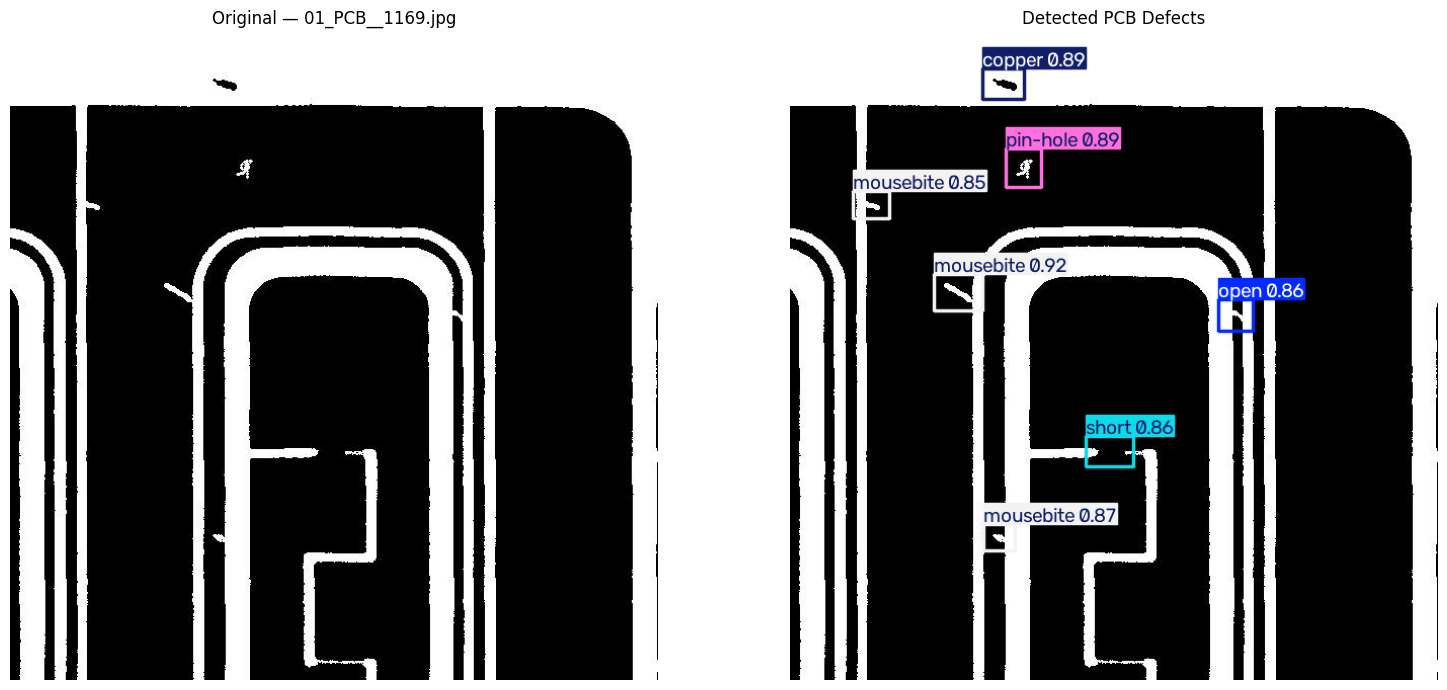

Image 1: 01_PCB__1169.jpg
mousebite           : 3
pin-hole            : 1
copper              : 1
short               : 1
open                : 1
------------------------------------------------------------
Total defects: 7
Inspection status: FAILED


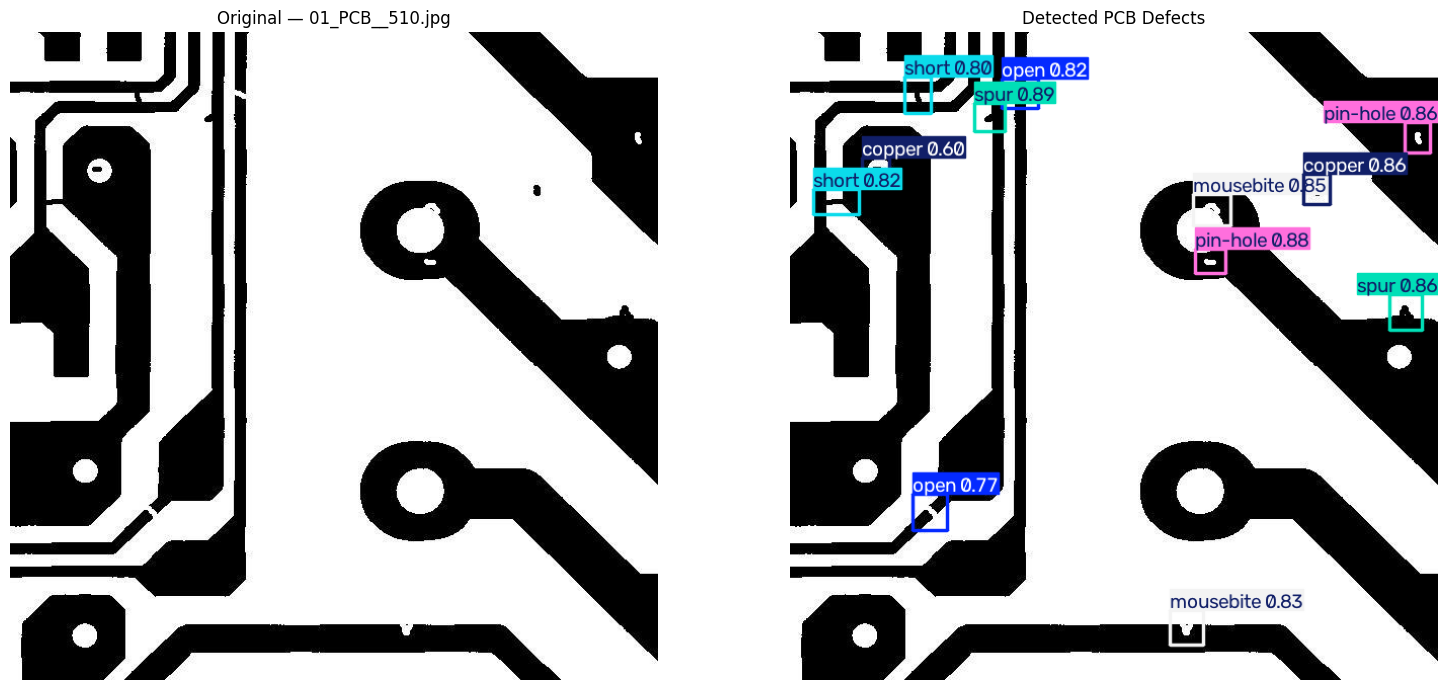

Image 2: 01_PCB__510.jpg
spur                : 2
pin-hole            : 2
copper              : 2
mousebite           : 2
short               : 2
open                : 2
------------------------------------------------------------
Total defects: 12
Inspection status: FAILED


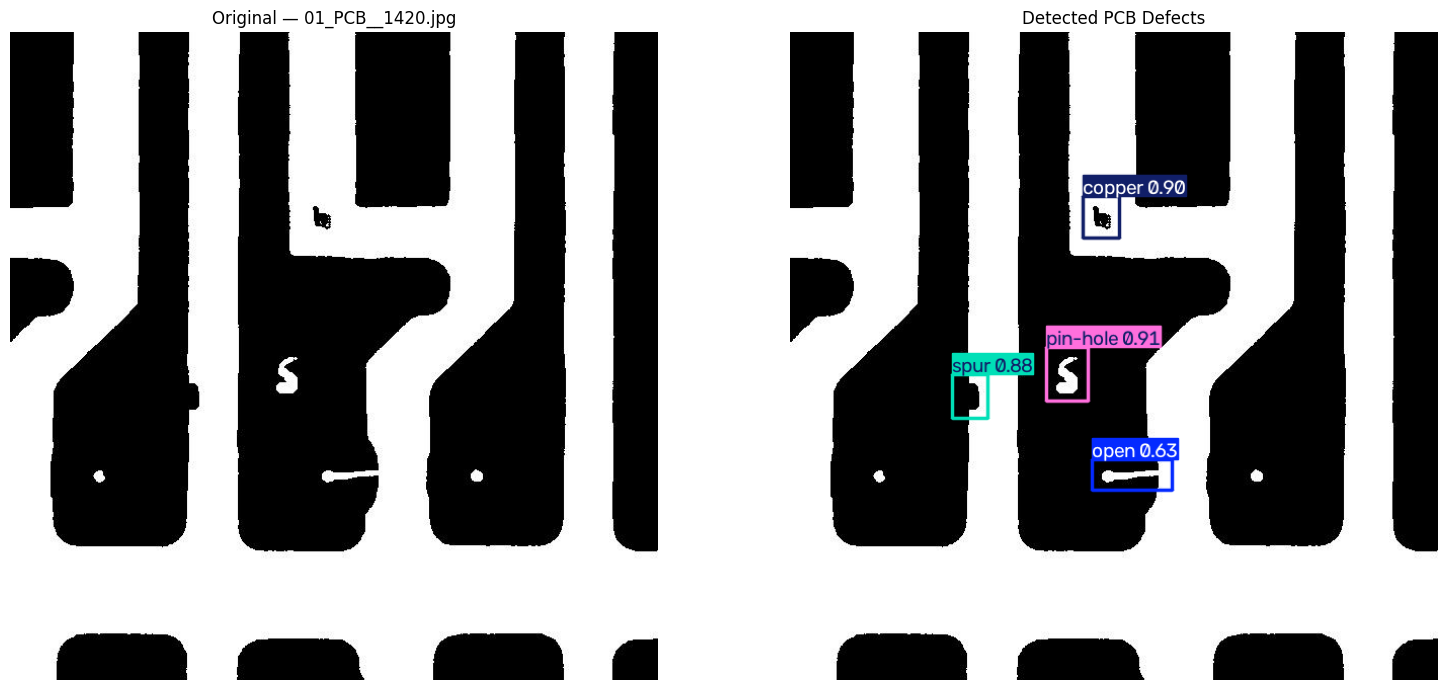

Image 3: 01_PCB__1420.jpg
pin-hole            : 1
copper              : 1
spur                : 1
open                : 1
------------------------------------------------------------
Total defects: 4
Inspection status: FAILED


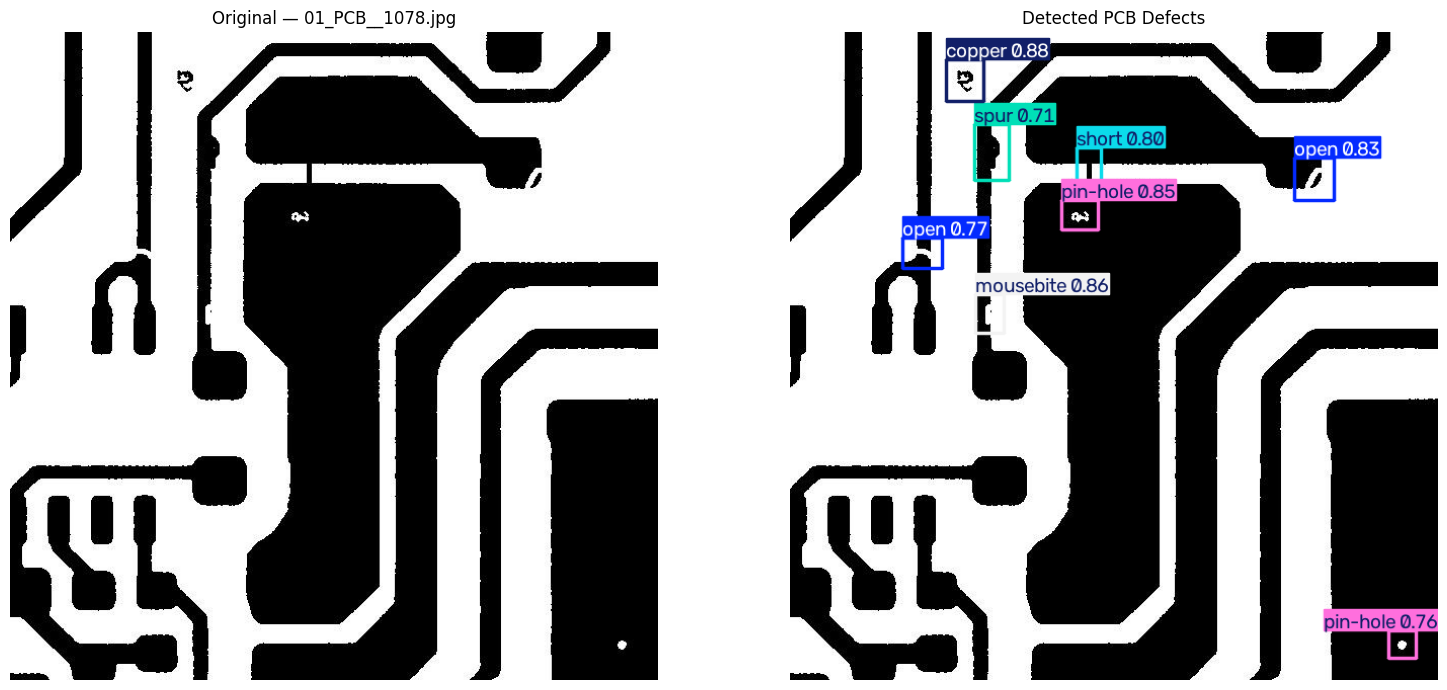

Image 4: 01_PCB__1078.jpg
copper              : 1
mousebite           : 1
pin-hole            : 2
open                : 2
short               : 1
spur                : 1
------------------------------------------------------------
Total defects: 8
Inspection status: FAILED


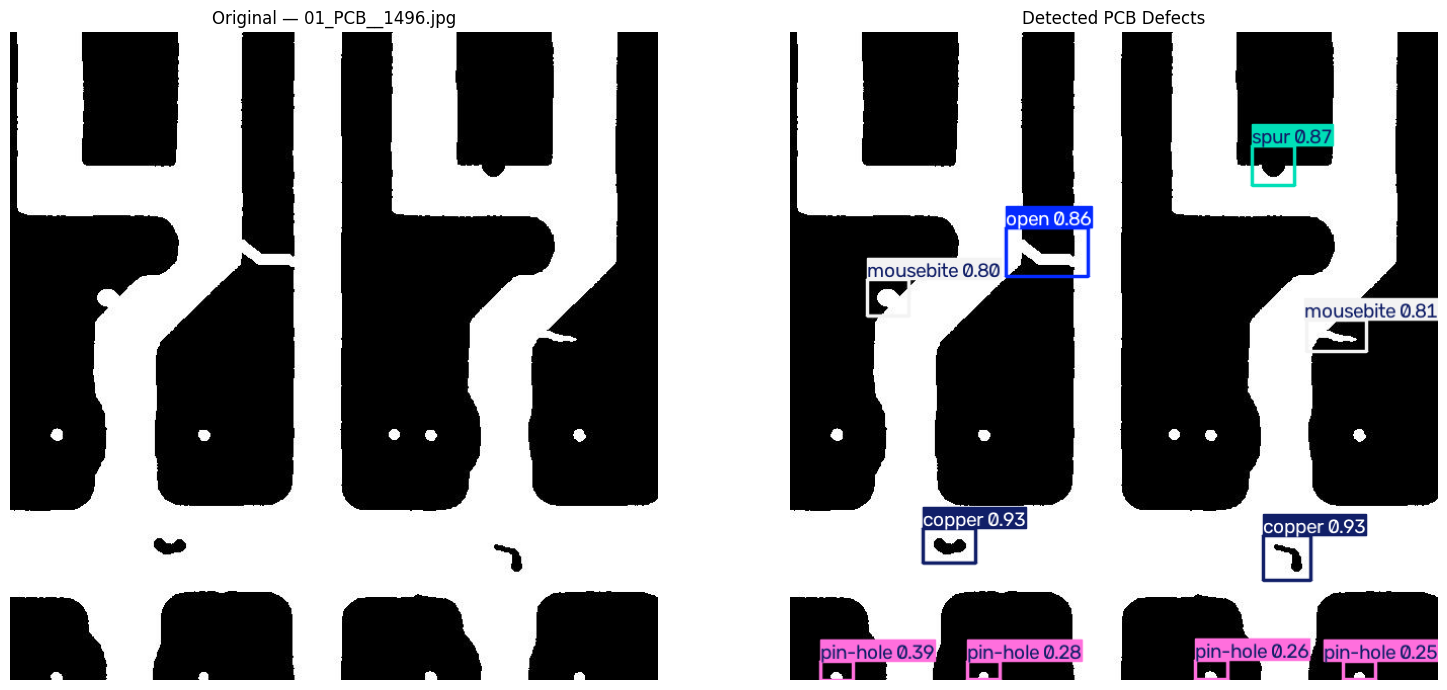

Image 5: 01_PCB__1496.jpg
copper              : 2
spur                : 1
open                : 1
mousebite           : 2
pin-hole            : 4
------------------------------------------------------------
Total defects: 10
Inspection status: FAILED


In [47]:
import random
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt

TEST_FOLDER = (
    BASE_DIR
    / "extracted_dataset"
    / "DeepPCB"
    / "test"
    / "images"
)

image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

all_images = [
    image_path
    for image_path in TEST_FOLDER.iterdir()
    if image_path.suffix.lower() in image_extensions
]

selected_images = random.sample(
    all_images,
    min(5, len(all_images))
)

for index, test_image in enumerate(selected_images, start=1):

    results = deep_model.predict(
        source=str(test_image),
        imgsz=640,
        conf=0.25,
        device=0,
        verbose=False
    )

    result = results[0]
    counts = Counter()

    if result.boxes is not None and len(result.boxes) > 0:
        for class_id in result.boxes.cls.cpu().numpy().astype(int):
            counts[result.names[class_id]] += 1

    original = Image.open(test_image).convert("RGB")
    detected = result.plot()[:, :, ::-1]

    plt.figure(figsize=(16, 7))

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title(f"Original — {test_image.name}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(detected)
    plt.title("Detected PCB Defects")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("=" * 60)
    print(f"Image {index}: {test_image.name}")
    print("=" * 60)

    if counts:
        for defect, count in counts.items():
            print(f"{defect:<20}: {count}")
    else:
        print("No defects detected.")

    total = sum(counts.values())

    print("-" * 60)
    print("Total defects:", total)
    print("Inspection status:", "FAILED" if total > 0 else "PASSED")

In [49]:
!pip install absl-py tensorflow

Defaulting to user installation because normal site-packages is not writeable
Could not fetch URL https://pypi.org/simple/pip/: There was a problem confirming the ssl certificate: HTTPSConnectionPool(host='pypi.org', port=443): Max retries exceeded with url: /simple/pip/ (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1000)'))) - skipping


In [ ]:
from ultralytics import YOLO

model = YOLO("training_runs/deeppcb_yolov8n/weights/best.pt")

onnx_path = model.export(
    format="onnx",
    imgsz=640
)

print("ONNX model exported successfully!")
print("Saved at:", onnx_path)

In [1]:
import os
print(os.getcwd())

/home/jupyter-svecwai/Subbarao/anamoly_rv
